# Data exploration

### Imports

In [27]:
from config import ExperimentConfig
from dataset import prepare_data
from dataset import build_val_transform
from PIL import Image as PILImage

import sys
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Testing data preparation

The data pipeline:
1. Loads `train.csv` with (Image, Id) pairs
2. Uses a hybrid split: stratifies classes with enough samples and keeps ultra-rare classes in training to make testing more "fair"
3. Excludes `new_whale` from training (it's not a class — it's the *absence* of a known class)
4. Keeps `new_whale` in validation to track open-set detection performance
5. Builds contiguous class indices for the known whale identities

In [28]:
# These are the splits we will use in the actual analysis
config = ExperimentConfig(
    experiment_name="test_prepare_data",
    description="Just testing preparing data",
    test_split = 0.1,
    val_split = 0.1,
    min_samples_per_class = 1,
    stratified_split = True,
    data_dir="data")

data = prepare_data(config)

print(f"\nClass mapping: {data['num_classes']} known whale identities")
print(f"ID → Index examples: {dict(list(data['id_to_idx'].items())[:5])} ...")


[split] Stratified test split infeasible on frequent classes; using shuffled split.
[split] Stratified val split infeasible on frequent classes; using shuffled split.
Dataset split:
  Train:    8089 images, 4247 known classes (filtered 647 new_whale)
  Val:       557 images (88 are new_whale)
  Test:      557 images (75 are new_whale)
  Class distribution: min=1 median=1 max=24 samples/class

Class mapping: 4247 known whale identities
ID → Index examples: {'w_0013924': 0, 'w_001ebbc': 1, 'w_002222a': 2, 'w_002b682': 3, 'w_002dc11': 4} ...


### Amount of images per class

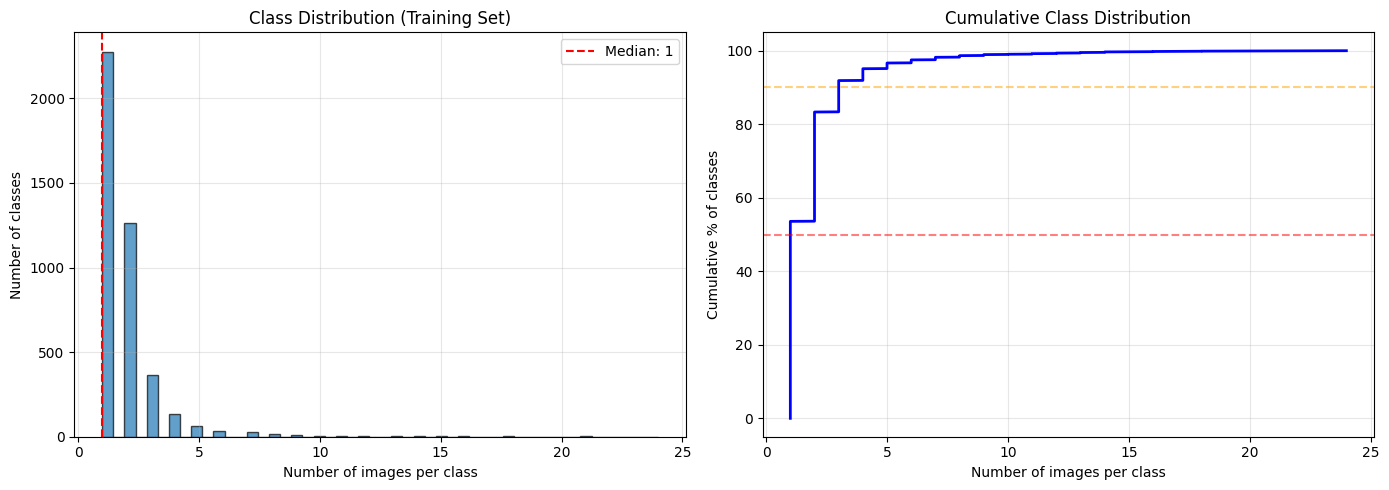

Key statistics:
Total amount of classes:   4247
Classes with 1 image:   2276 (53.6%)
Classes with 2 images: 1263 (29.7%)
Classes with 3 images: 363 (8.5%)
Classes with <= 3 images: 3902 (91.9%)


In [29]:
# Class distribution analysis

class_counts = data["class_counts"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of samples per class
ax = axes[0]
ax.hist(class_counts, bins=50, edgecolor="black", alpha=0.7)
ax.set_xlabel("Number of images per class")
ax.set_ylabel("Number of classes")
ax.set_title("Class Distribution (Training Set)")
ax.axvline(x=np.median(class_counts), color="red", linestyle="--",
           label=f"Median: {np.median(class_counts):.0f}")
ax.legend()
ax.grid(True, alpha=0.3)

# Cumulative: what fraction of classes have ≤ N images?
ax = axes[1]
sorted_counts = np.sort(class_counts)
cumulative = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts) * 100
ax.plot(sorted_counts, cumulative, "b-", linewidth=2)
ax.set_xlabel("Number of images per class")
ax.set_ylabel("Cumulative % of classes")
ax.set_title("Cumulative Class Distribution")
ax.axhline(y=50, color="red", linestyle="--", alpha=0.5)
ax.axhline(y=90, color="orange", linestyle="--", alpha=0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('img/class_distribution.png', bbox_inches='tight', dpi=300)
plt.show()

print("Key statistics:")
print(f"Total amount of classes:   {len(class_counts)}")
print(f"Classes with 1 image:   {(class_counts == 1).sum()} ({(class_counts == 1).sum() / len(class_counts) * 100:.1f}%)")
print(f"Classes with 2 images: {(class_counts == 2).sum()} ({(class_counts == 2).sum() / len(class_counts) * 100:.1f}%)")
print(f"Classes with 3 images: {(class_counts == 3).sum()} ({(class_counts == 3).sum() / len(class_counts) * 100:.1f}%)")
print(f"Classes with <= 3 images: {(class_counts <= 3).sum()} ({(class_counts <= 3).sum() / len(class_counts) * 100:.1f}%)")



### Sample images

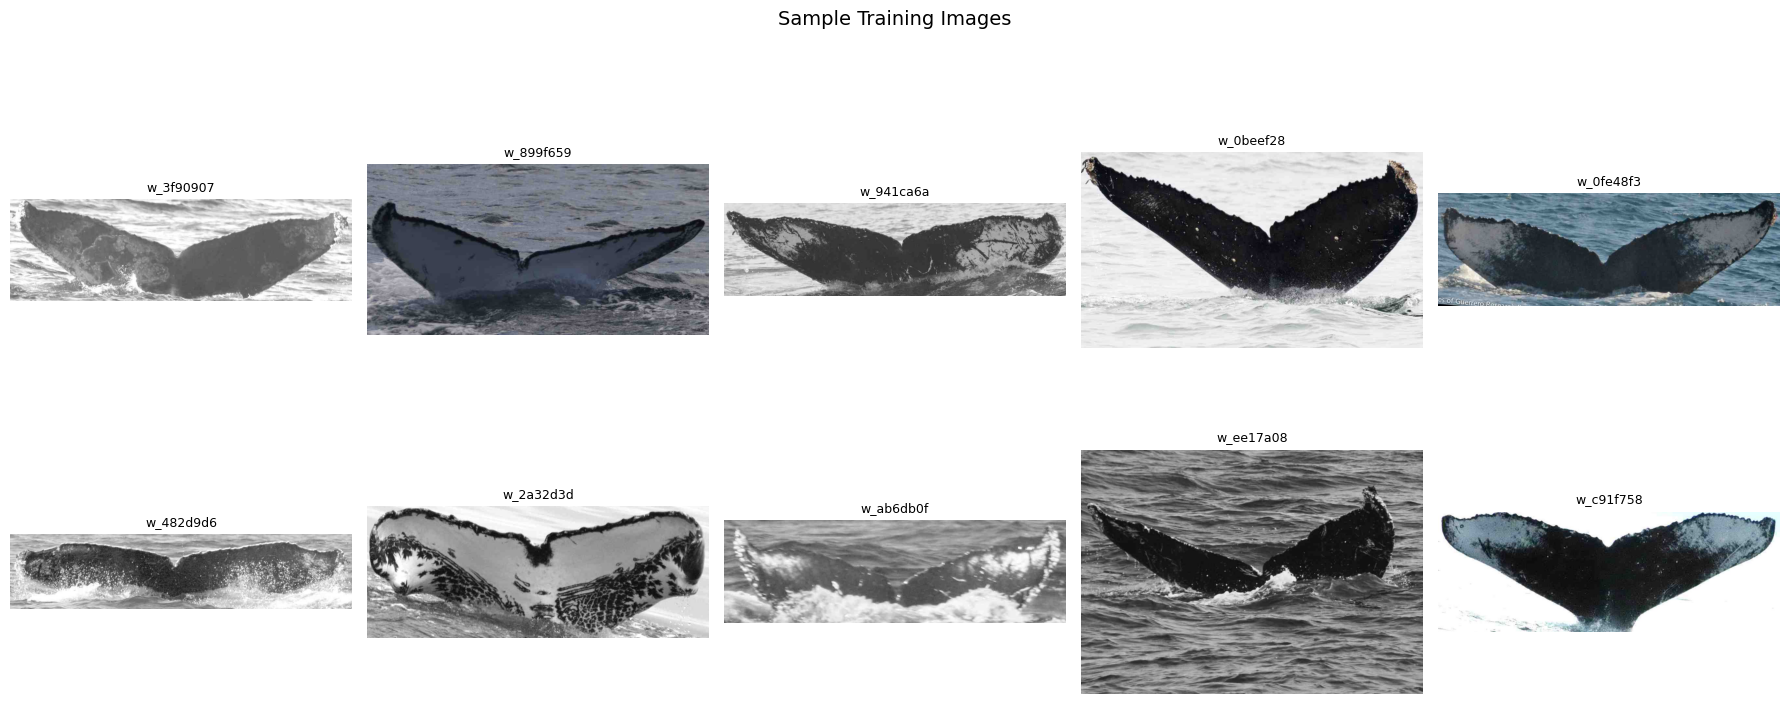

In [30]:
# Show a few training images with their labels
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
sample_df = data["train_df"].sample(10, random_state=42)
transform = build_val_transform(config)

for i, (_, row) in enumerate(sample_df.iterrows()):
    ax = axes[i // 5, i % 5]
    img_path = os.path.join(config.data_dir, "train", row["Image"])
    try:
        img = PILImage.open(img_path).convert("RGB")
        ax.imshow(img)
        ax.set_title(row["Id"][:15], fontsize=9)
    except Exception as e:
        ax.text(0.5, 0.5, f"Load error: {e}", ha="center")
    ax.axis("off")

plt.suptitle("Sample Training Images", fontsize=14)
plt.tight_layout()
plt.show()


### Test DataLoaders

Augmentation philosophy for whale flukes:
- **YES**: Mild rotation, brightness/contrast jitter, slight crop variation, gentle blur
- **NO**: Horizontal flip (left/right notch patterns are identity-specific),
  random erasing (could delete the exact notch that identifies the whale),
  heavy geometric distortion (changes trailing-edge shape)


Train batches: 674 (micro-batch=12, effective=24)
Val batches:   24


c:\Users\Sebastian Munthe\Desktop\ml4cv_final\ML4CV\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


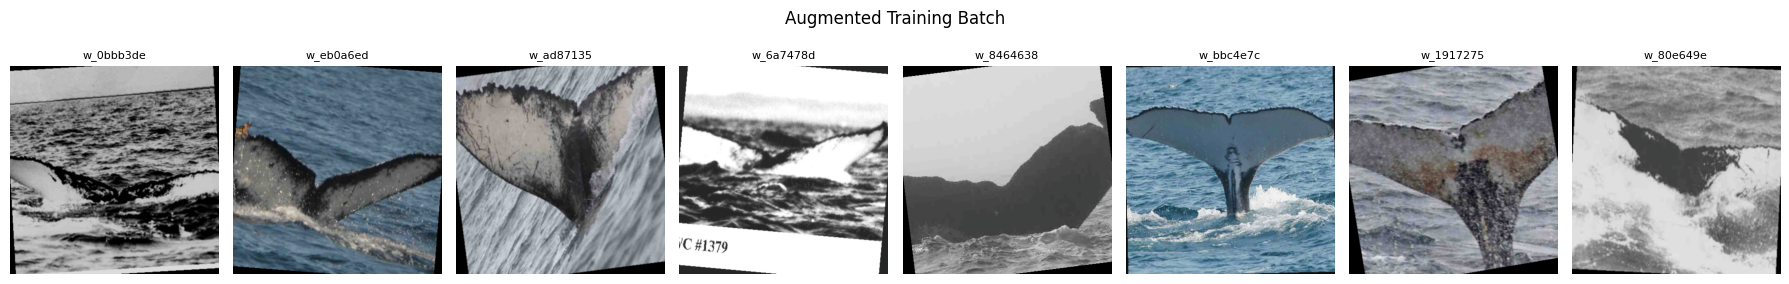

In [31]:
from dataset import build_dataloaders

train_loader, val_loader = build_dataloaders(config, data)

print(f"Train batches: {len(train_loader)} (micro-batch={config.batch_size}, "
      f"effective={config.batch_size * config.accumulation_steps})")
print(f"Val batches:   {len(val_loader)}")

# Show a batch with augmentation applied
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, min(8, len(images)), figsize=(18, 3))

# Denormalize for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

for i, ax in enumerate(axes):
    img = images[i].cpu() * std + mean
    img = img.permute(1, 2, 0).clamp(0, 1).numpy()
    ax.imshow(img)
    label = labels[i].item()
    id_str = data["idx_to_id"].get(label, "new_whale") if label >= 0 else "new_whale"
    ax.set_title(f"{id_str[:12]}", fontsize=8)
    ax.axis("off")

plt.suptitle("Augmented Training Batch", fontsize=12)
plt.tight_layout()
plt.show()


## Duplicates in data?

Hashing …
  647 images not in any split (new_whale/rare dropped from train) — excluded.
  9203 images kept.
  599 exact-duplicate pairs.



,bucket,pairs,images_affected,pool (known-test),pool (known-train),pool (known-val),pool (new-test),pool (new-val)
0,known-train × known-train,401,802,NaN,8089.0,NaN,NaN,NaN
1,known-train × known-val,77,154,NaN,8089.0,469.0,NaN,NaN
2,known-test × known-train,71,142,482.0,8089.0,NaN,NaN,NaN
3,known-train × new-val,20,40,NaN,8089.0,NaN,NaN,88.0
4,known-test × known-val,10,20,482.0,NaN,469.0,NaN,NaN
5,known-train × new-test,8,16,NaN,8089.0,NaN,75.0,NaN
6,known-test × known-test,5,10,482.0,NaN,NaN,NaN,NaN
7,known-val × known-val,3,6,NaN,NaN,469.0,NaN,NaN
8,known-val × new-test,2,4,NaN,NaN,469.0,75.0,NaN
9,known-test × new-test,1,2,482.0,NaN,NaN,75.0,NaN



[known-test  ×  known-test]  5 pairs · 10 affected (pool: known-test=482, known-test=482)


,image_a,id_a,split_a,image_b,id_b,split_b
0,02af1aa3.jpg,w_5624f08,test,0aa416d8.jpg,w_5624f08,test
1,1990152d.jpg,w_92d390e,test,80e1ee26.jpg,w_92d390e,test


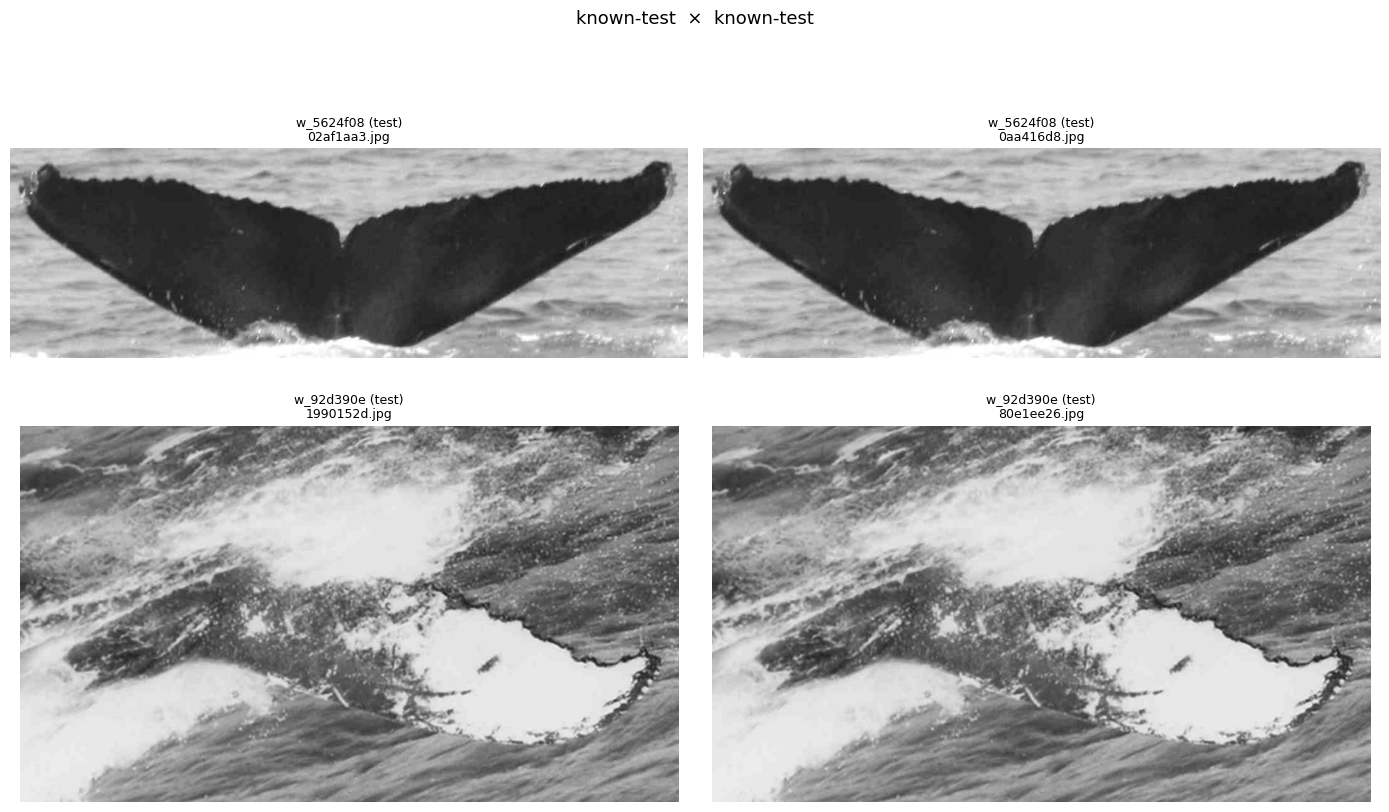


[known-test  ×  known-train]  71 pairs · 142 affected (pool: known-test=482, known-train=8089)


,image_a,id_a,split_a,image_b,id_b,split_b
0,096f4caa.jpg,w_2b443f8,test,6f660c6d.jpg,w_2b443f8,train
1,8224f7c6.jpg,w_dc7c5a0,train,a35d3e18.jpg,w_dc7c5a0,test


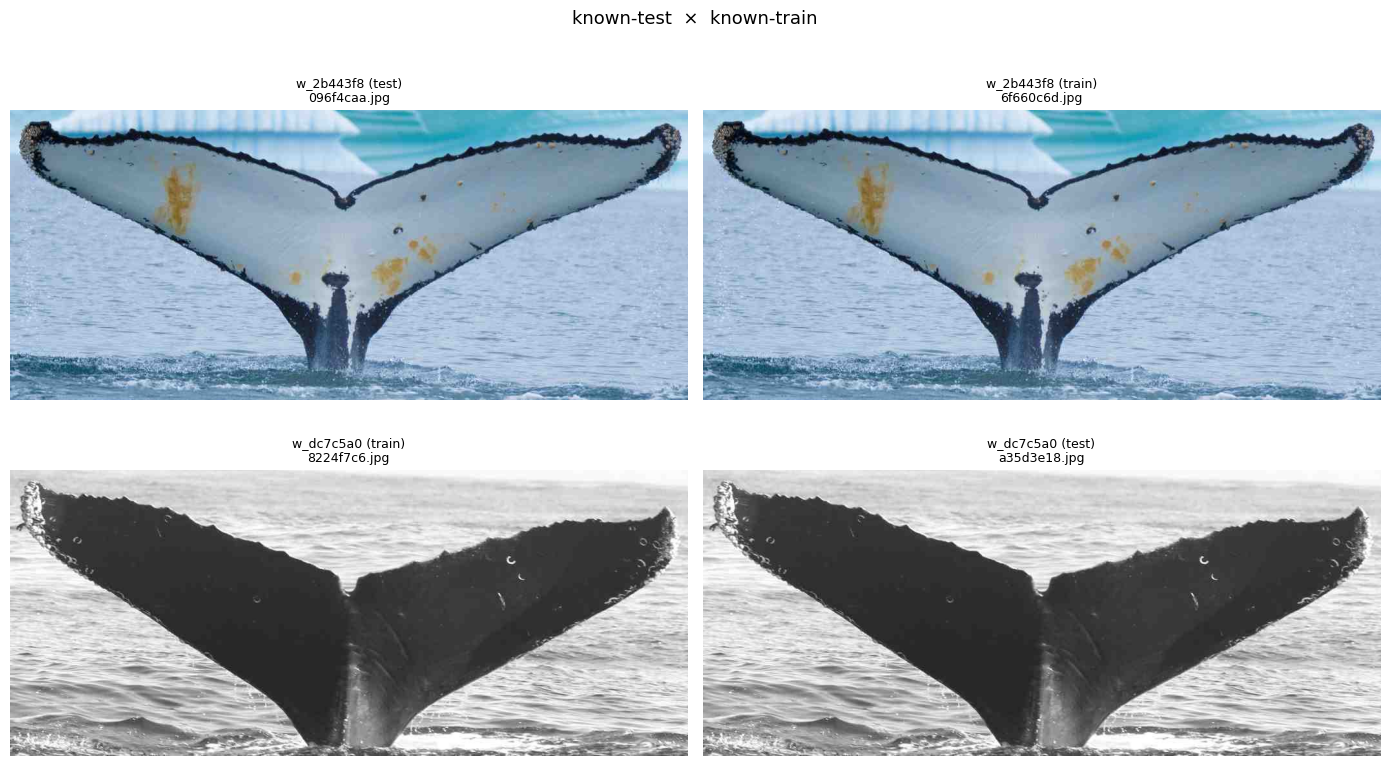


[known-test  ×  known-val]  10 pairs · 20 affected (pool: known-test=482, known-val=469)


,image_a,id_a,split_a,image_b,id_b,split_b
0,d11b57b4.jpg,w_372ae75,test,ef9f23dc.jpg,w_372ae75,val
1,19546e12.jpg,w_7885601,test,c6d31eca.jpg,w_7885601,val


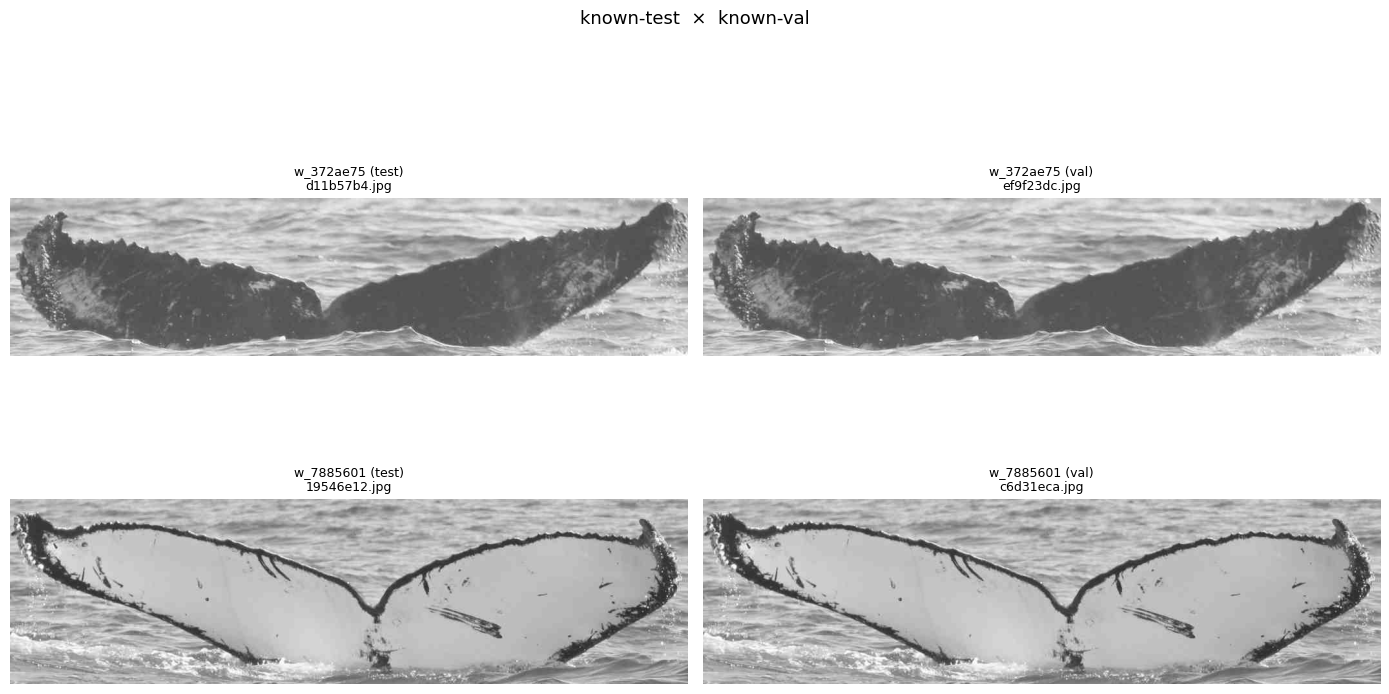


[known-test  ×  new-test]  1 pairs · 2 affected (pool: known-test=482, new-test=75)


,image_a,id_a,split_a,image_b,id_b,split_b
0,67758056.jpg,w_d8e752e,test,9cd2fa20.jpg,new_whale,test


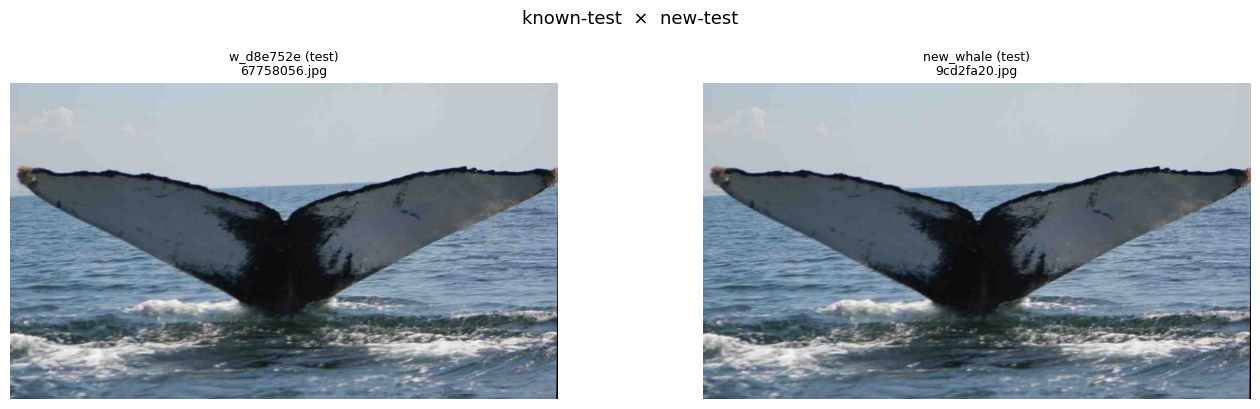


[known-train  ×  known-train]  401 pairs · 802 affected (pool: known-train=8089, known-train=8089)


,image_a,id_a,split_a,image_b,id_b,split_b
0,a6d0e8a5.jpg,w_9b401eb,train,f68bb972.jpg,w_9b401eb,train
1,8f1fb719.jpg,w_1287fbc,train,f5ac7c84.jpg,w_1287fbc,train


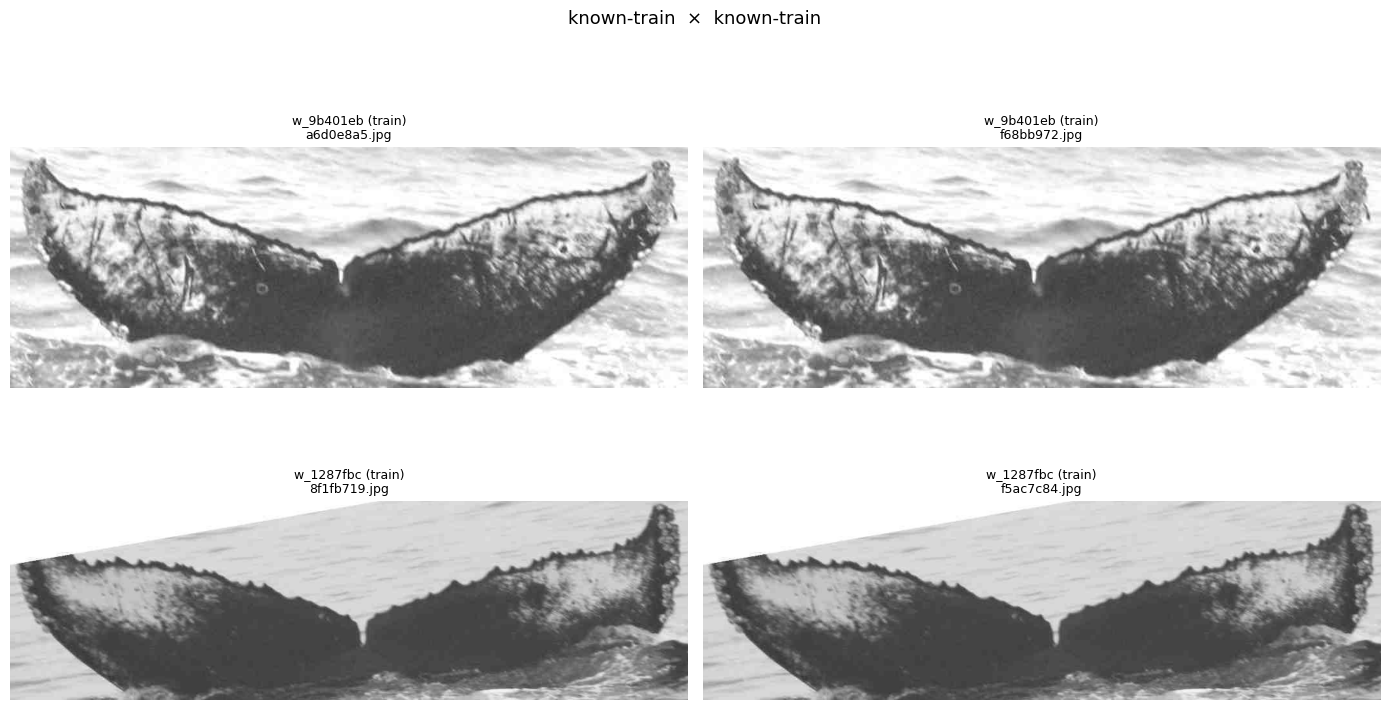


[known-train  ×  known-val]  77 pairs · 154 affected (pool: known-train=8089, known-val=469)


,image_a,id_a,split_a,image_b,id_b,split_b
0,29406608.jpg,w_0988bbb,val,9bb38476.jpg,w_0988bbb,train
1,a60936fb.jpg,w_f1a4389,val,b756d005.jpg,w_f1a4389,train


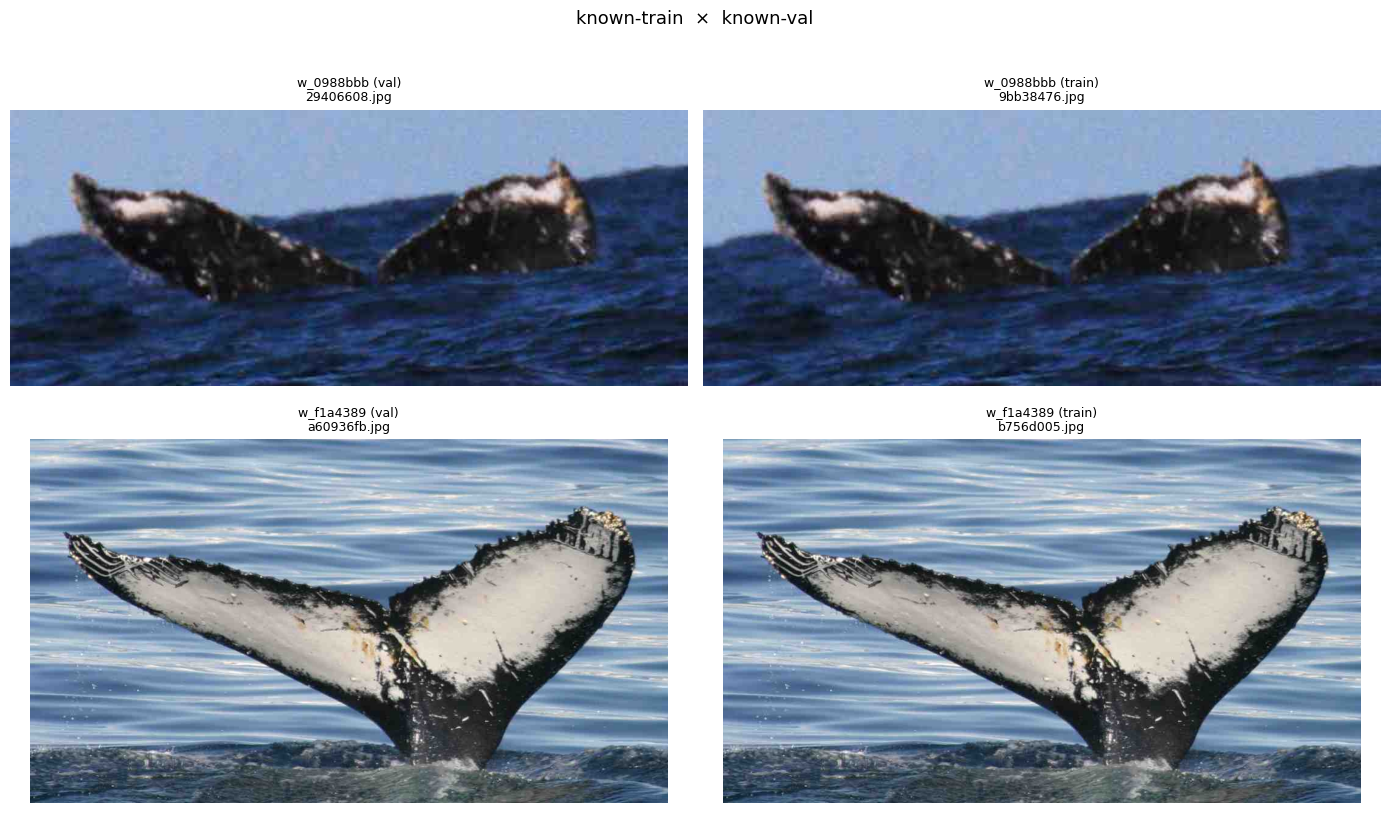


[known-train  ×  new-test]  8 pairs · 16 affected (pool: known-train=8089, new-test=75)


,image_a,id_a,split_a,image_b,id_b,split_b
0,2eb590c7.jpg,new_whale,test,941479c5.jpg,w_41a79d7,train
1,03933dbb.jpg,new_whale,test,eea93983.jpg,w_18eee6e,train


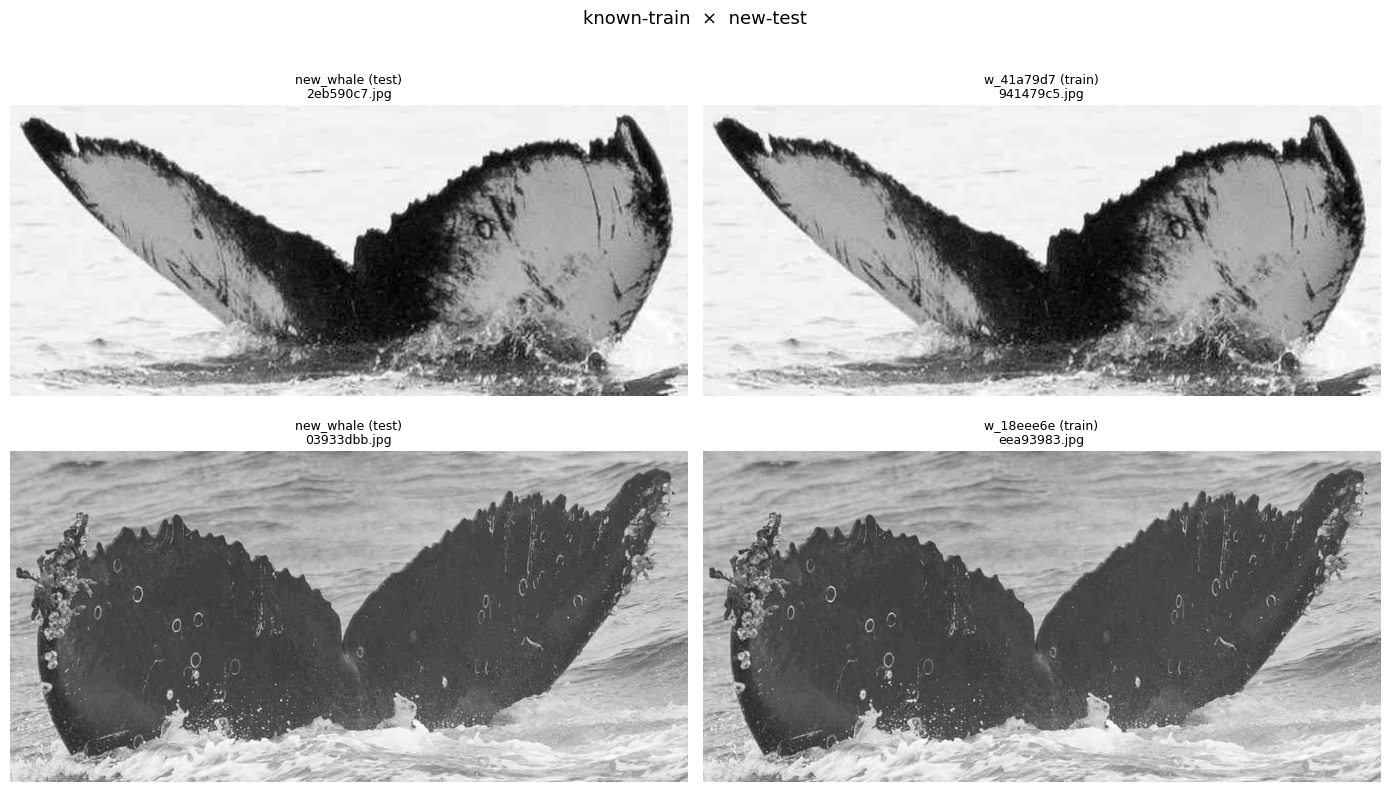


[known-train  ×  new-val]  20 pairs · 40 affected (pool: known-train=8089, new-val=88)


,image_a,id_a,split_a,image_b,id_b,split_b
0,47d88de7.jpg,new_whale,val,feb32d26.jpg,w_b17f9ea,train
1,2f899d4d.jpg,w_dcb1f2a,train,46b7dba5.jpg,new_whale,val


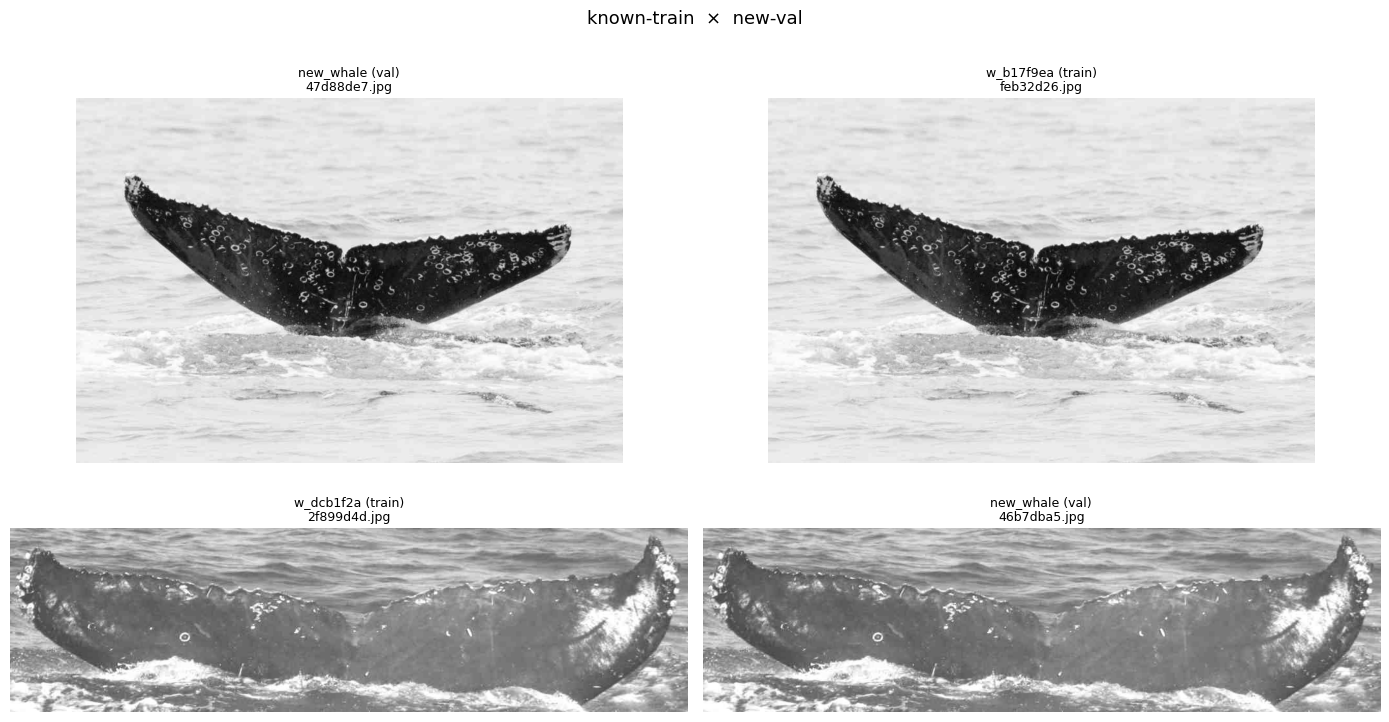


[known-val  ×  known-val]  3 pairs · 6 affected (pool: known-val=469, known-val=469)


,image_a,id_a,split_a,image_b,id_b,split_b
0,0323fcfc.jpg,w_cd22b23,val,cf5c4d4a.jpg,w_cd22b23,val
1,2c3b34a3.jpg,w_1287fbc,val,3cdd7fa7.jpg,w_1287fbc,val


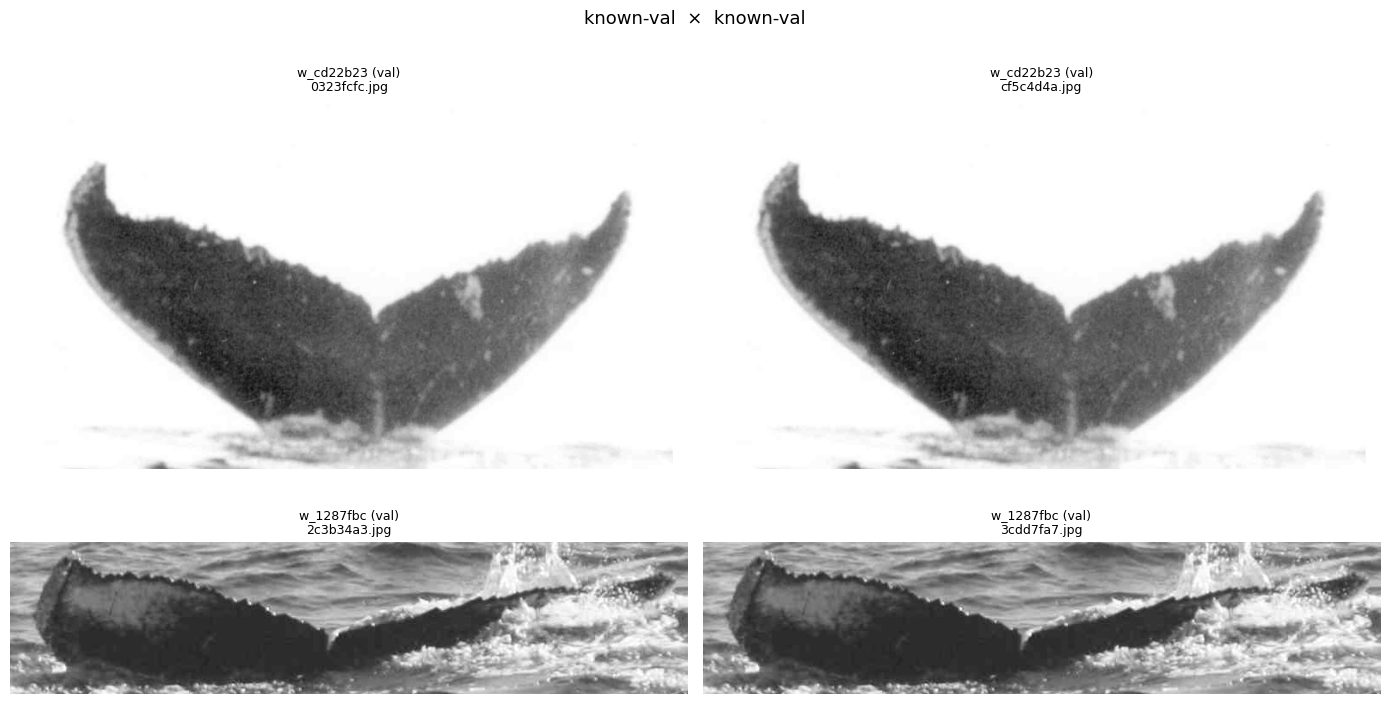


[known-val  ×  new-test]  2 pairs · 4 affected (pool: known-val=469, new-test=75)


,image_a,id_a,split_a,image_b,id_b,split_b
0,973d410c.jpg,w_d96a0cd,val,e0dda879.jpg,new_whale,test
1,7310c41a.jpg,w_5436d75,val,af079b53.jpg,new_whale,test


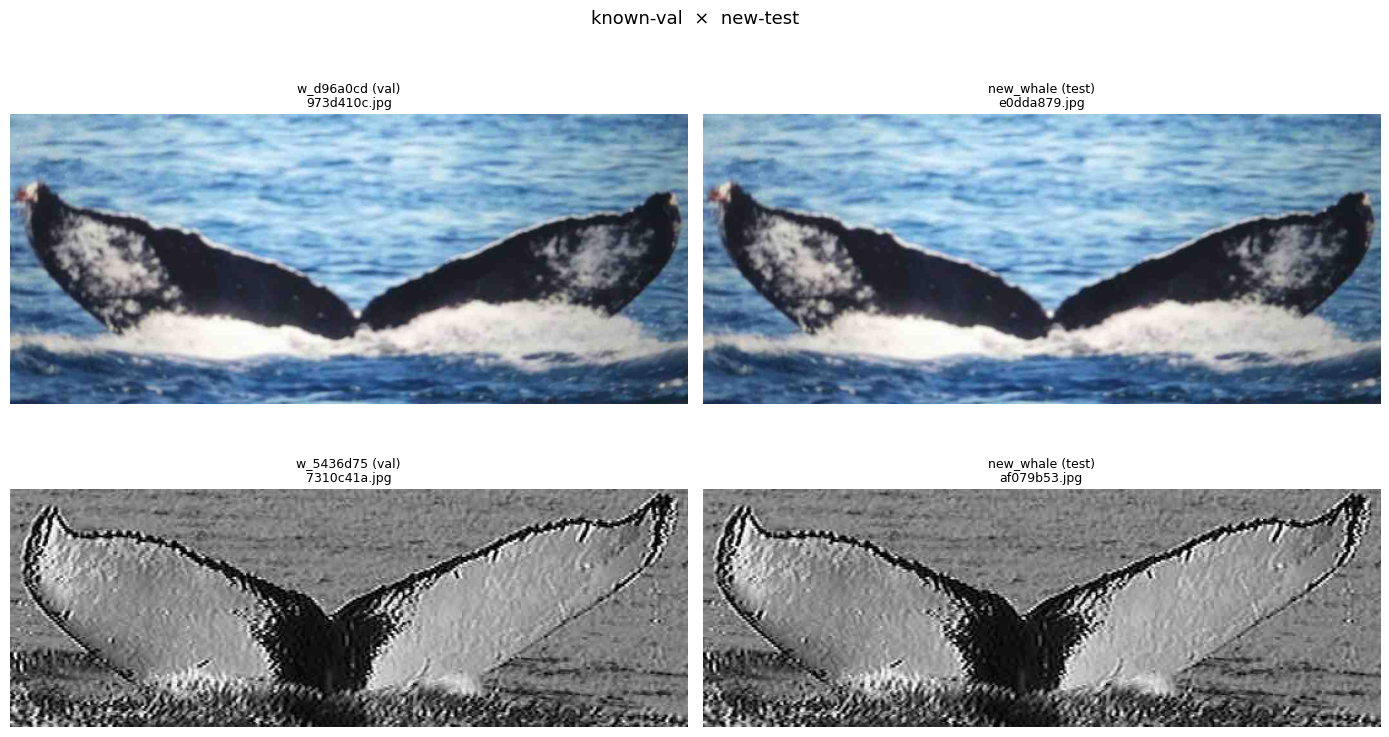


[known-val  ×  new-val]  1 pairs · 2 affected (pool: known-val=469, new-val=88)


,image_a,id_a,split_a,image_b,id_b,split_b
0,28624189.jpg,new_whale,val,b5f46cf1.jpg,w_bb2d34d,val


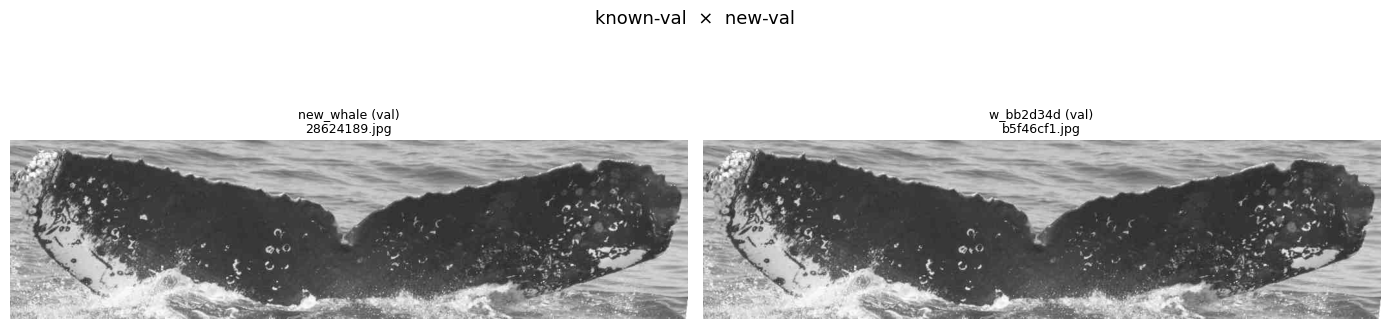


Done.


In [33]:
# --- Exact duplicate audit: split-aware cross-tab + spot-check samples ---
# Requires: `data` dict from prepare_data already in scope, images under data/train/

import hashlib
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

IMAGE_ROOT = Path("data") / "train"

# ── 1. Fingerprint ───────────────────────────────────────────────────────

fp_df = pd.read_csv(Path("data") / "train.csv")[["Image", "Id"]].copy()
fp_df["path"] = fp_df["Image"].map(lambda n: IMAGE_ROOT / n)
fp_df = fp_df[fp_df["path"].map(Path.exists)].reset_index(drop=True)


def _sha1(p):
    h = hashlib.sha1()
    with open(p, "rb") as f:
        for blk in iter(lambda: f.read(1 << 20), b""):
            h.update(blk)
    return h.hexdigest()


print("Hashing …")
fp_df["sha1"] = fp_df["path"].map(_sha1)

# ── 2. Split tags from existing `data` (no re-calling prepare_data) ──────

split_map = {img: "train" for img in data["train_df"]["Image"]}
split_map.update({img: "val" for img in data["val_df"]["Image"]})
split_map.update({img: "test" for img in data["test_df"]["Image"]})

fp_df["split"] = fp_df["Image"].map(split_map)
n_dropped = fp_df["split"].isna().sum()
if n_dropped:
    print(f"  {n_dropped} images not in any split (new_whale/rare dropped from train) — excluded.")
fp_df = fp_df.dropna(subset=["split"]).reset_index(drop=True)
fp_df["family"] = np.where(fp_df["Id"] == "new_whale", "new", "known")
fp_df["side"] = fp_df["family"] + "-" + fp_df["split"]
print(f"  {len(fp_df)} images kept.")

pool = fp_df["side"].value_counts().to_dict()

# ── 3. Exact-duplicate pairs ─────────────────────────────────────────────

pair_rows = []
for _, grp in fp_df.groupby("sha1"):
    if len(grp) < 2:
        continue
    for ia, ib in itertools.combinations(grp.index, 2):
        a, b = fp_df.loc[ia], fp_df.loc[ib]
        sa, sb = a["side"], b["side"]
        side1, side2 = sorted([sa, sb])
        pair_rows.append({
            "image_a": a["Image"], "id_a": a["Id"],
            "split_a": a["split"], "family_a": a["family"], "side_a": sa,
            "image_b": b["Image"], "id_b": b["Id"],
            "split_b": b["split"], "family_b": b["family"], "side_b": sb,
            "side_1": side1, "side_2": side2,
            "bucket": f"{side1}  ×  {side2}",
        })

pairs = pd.DataFrame(pair_rows)
print(f"  {len(pairs)} exact-duplicate pairs.\n")


# ── 4. Cross-tab ─────────────────────────────────────────────────────────

def _affected(sub):
    return set(sub["image_a"]) | set(sub["image_b"])


if len(pairs):
    rows = []
    for bucket, g in pairs.groupby("bucket"):
        s1, s2 = g.iloc[0]["side_1"], g.iloc[0]["side_2"]
        n_aff = len(_affected(g))
        rows.append({
            "bucket": bucket,
            "pairs": len(g),
            "images_affected": n_aff,
            f"pool ({s1})": pool.get(s1, 0),
            f"pool ({s2})": pool.get(s2, 0),
        })
    ct = pd.DataFrame(rows).sort_values("pairs", ascending=False).reset_index(drop=True)
    display(ct)
else:
    print("No exact-duplicate pairs found.")

# ── 5. Spot-check (≤2 samples per bucket) ────────────────────────────────

resample = getattr(Image, "Resampling", Image).BILINEAR

buckets_to_show = sorted(pairs["bucket"].unique()) if len(pairs) else []

for bucket in buckets_to_show:
    sub = pairs[pairs["bucket"] == bucket]
    aff = _affected(sub)
    s1, s2 = sub.iloc[0]["side_1"], sub.iloc[0]["side_2"]

    n = min(2, len(sub))
    samp = sub.sample(n=n, random_state=42).reset_index(drop=True)

    print(f"\n[{bucket}]  {len(sub)} pairs · {len(aff)} affected "
          f"(pool: {s1}={pool.get(s1,0)}, {s2}={pool.get(s2,0)})")
    display(samp[["image_a", "id_a", "split_a", "image_b", "id_b", "split_b"]])

    fig, axes = plt.subplots(n, 2, figsize=(14, 4 * n), squeeze=False)
    for i, r in samp.iterrows():
        a = Image.open(IMAGE_ROOT / r["image_a"]).convert("RGB")
        b = Image.open(IMAGE_ROOT / r["image_b"]).convert("RGB")
        w, h = min(a.width, b.width), min(a.height, b.height)
        ar, br = a.resize((w, h), resample), b.resize((w, h), resample)

        axes[i, 0].imshow(a); axes[i, 0].axis("off")
        axes[i, 0].set_title(f"{r['id_a']} ({r['split_a']})\n{r['image_a']}", fontsize=9)
        axes[i, 1].imshow(b); axes[i, 1].axis("off")
        axes[i, 1].set_title(f"{r['id_b']} ({r['split_b']})\n{r['image_b']}", fontsize=9)

    plt.suptitle(bucket, fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()

print("\nDone.")